# Expense Categorisation — Model Evaluation

**Salary-Linked Expense Tracker and Budget Advisor** · Sprint 2 · FR-02 / NFR-02

This notebook is the evaluation described in the project report (sections 3.7.3
and 3.7.4). It compares the two candidate classifiers — a **Multinomial Naive
Bayes** baseline and a **Random Forest** — on the transaction-categorisation
task, and checks the result against the **NFR-02 acceptance criterion of macro
F1 ≥ 0.85**.

It is fully reproducible and uses only **synthetic data** generated on the fly
(no real financial data, consistent with the ethics position in section 3.9).
Run the cells top to bottom.

## 1. Data preparation

The system's real pipeline is mirrored exactly: a synthetic bank statement is
generated, imported through the ingestion layer (which validates, deduplicates
and rule-seeds categories), and the labelled training frame is read back. This
is the same `training_frame` the production trainer uses, so the evaluation
measures the real feature set.

In [1]:
import os
import sys
import subprocess
import tempfile
import warnings

warnings.filterwarnings("ignore")

# Locate the project root whether this runs from notebooks/ or the repo root.
ROOT = os.path.abspath("..") if os.path.exists("../config.py") else os.path.abspath(".")
sys.path.insert(0, ROOT)

import config

# Point the app at a throwaway database so nothing touches the real data.
_tmp = tempfile.mkdtemp()
config.DATABASE_PATH = os.path.join(_tmp, "eval.db")
config.MODEL_DIR = os.path.join(_tmp, "models")
config.CATEGORISER_PATH = os.path.join(config.MODEL_DIR, "categoriser.joblib")
config.UPLOAD_FOLDER = os.path.join(_tmp, "uploads")

import database

database.init_db()
conn = database.get_db_connection()
conn.execute(
    "INSERT INTO User (full_name, salary_amount, salary_day) VALUES ('Demo', 8000, 30)"
)
conn.commit()

# Generate a synthetic 8-month statement and import it.
statement = os.path.join(_tmp, "statement.csv")
subprocess.run(
    [sys.executable, os.path.join(ROOT, "generate_sample_data.py"),
     "--months", "8", "--salary", "8000", "--salary-day", "30",
     "--output", statement],
    check=True, cwd=ROOT, capture_output=True,
)

from services import ingestion

report = ingestion.import_statement(conn, 1, statement)
ingestion.post_import_pipeline(conn, 1)
print(f"Imported {report['imported']} transactions "
      f"({report['salary_rows']} salary credits identified).")

Imported 255 transactions (7 salary credits identified).


In [2]:
from ml import categorization

frame = categorization.training_frame(conn, user_id=1)
print(f"{len(frame)} labelled DEBIT transactions across "
      f"{frame['category_name'].nunique()} categories\n")
frame["category_name"].value_counts()

248 labelled DEBIT transactions across 12 categories



category_name
Transport         52
Groceries         38
Dining Out        32
Airtime & Data    24
Subscriptions     24
Utilities         18
Healthcare        14
Personal Care     11
Entertainment     11
Housing            8
Shopping           8
Loan & Debt        8
Name: count, dtype: int64

## 2. The feature set

Per section 3.7.2, the two models do **not** share a feature space:

- **Naive Bayes (baseline)** uses only the **TF-IDF** of the merchant text.
- **Random Forest** additionally uses the **normalised amount** and the
  **day-of-week / day-of-month**, which carry the payday and bill-cycle timing
  that can separate fixed recurring charges from ad-hoc spending.

`training_frame` returns all of these columns; each model's pipeline selects
what it uses via a `ColumnTransformer`.

In [3]:
frame[categorization.FEATURE_COLUMNS].head(8)

,text,amount,day_of_week,day_of_month
0,rent payment landlord,2100.00,6,1
1,shoprite cairo rd,507.70,6,1
2,total filling station,524.11,6,1
3,kfc cairo road,238.09,0,2
4,mr price clothing,183.93,0,2
5,mtn data bundle,38.07,0,2
6,taxi fare town,69.99,1,3
7,airtel airtime recharge,32.22,1,3


## 3. Cross-validated comparison

Both classifiers are evaluated with **stratified 5-fold cross-validation**
(section 3.7.4). Cross-validation is preferred to a single train/test split
because it gives a more reliable estimate of out-of-sample performance when
data is limited. The fold count is capped by the rarest class so every fold
contains every category.

In [4]:
from ml import evaluation

results, n_splits = evaluation.evaluate_candidates(frame)
print(f"{n_splits}-fold stratified cross-validation\n")

import pandas as pd

summary = pd.DataFrame({
    name: {"macro F1": r["macro_f1"], "accuracy": r["accuracy"]}
    for name, r in results.items()
}).T.round(4)
summary

5-fold stratified cross-validation



,macro F1,accuracy
MultinomialNB,0.9937,0.9960
RandomForest,0.9918,0.9919


In [5]:
best_name, best_f1 = evaluation.best_model(results)
target = config.TARGET_F1
print(f"Selected model      : {best_name}")
print(f"Macro F1            : {best_f1:.4f}")
print(f"NFR-02 target       : {target}")
print(f"Meets NFR-02        : {'YES' if evaluation.meets_target(best_f1) else 'NO'}")

Selected model      : MultinomialNB
Macro F1            : 0.9937
NFR-02 target       : 0.85
Meets NFR-02        : YES


## 4. Per-category performance

Macro F1 averages the per-category scores **regardless of support**, so a
category with two examples counts as much as one with fifty. The per-category
table below is the honest view: it shows where the model is strong and which
categories have too little data to trust.

In [6]:
report_dict = results[best_name]["report"]
labels = results[best_name]["labels"]
per_category = pd.DataFrame(
    {c: report_dict[c] for c in labels}
).T[["precision", "recall", "f1-score", "support"]]
per_category = per_category.sort_values("f1-score")
per_category.round(3)

,precision,recall,f1-score,support
Shopping,1.000,0.875,0.933,8.0
Transport,0.981,1.000,0.990,52.0
Airtime & Data,1.000,1.000,1.000,24.0
Dining Out,1.000,1.000,1.000,32.0
Healthcare,1.000,1.000,1.000,14.0
Housing,1.000,1.000,1.000,8.0
Entertainment,1.000,1.000,1.000,11.0
Groceries,1.000,1.000,1.000,38.0
Personal Care,1.000,1.000,1.000,11.0
Loan & Debt,1.000,1.000,1.000,8.0


## 5. Confusion matrix

The confusion matrix for the selected model shows exactly which categories are
mistaken for which — the diagnostic the report uses to justify the model
choice.

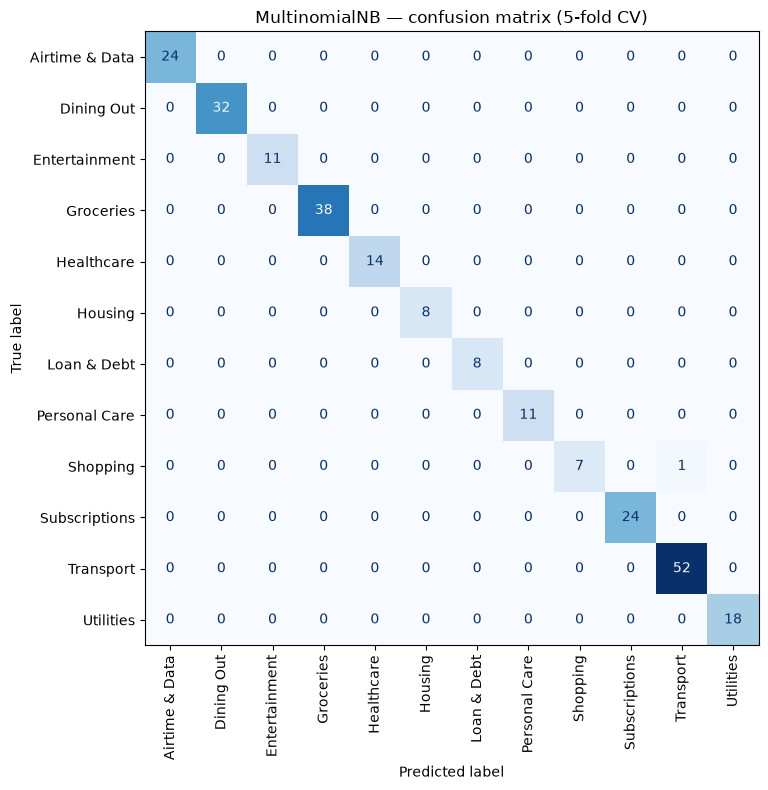

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

r = results[best_name]
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(
    confusion_matrix=r["confusion"], display_labels=r["labels"]
).plot(ax=ax, xticks_rotation="vertical", colorbar=False, cmap="Blues")
ax.set_title(f"{best_name} — confusion matrix ({n_splits}-fold CV)")
plt.tight_layout()
plt.show()

## 6. Findings and caveats

**Result.** Both classifiers comfortably clear the NFR-02 target of macro
F1 ≥ 0.85. On this clean synthetic data Naive Bayes and Random Forest score
almost identically: the merchant descriptions are highly separable, so the
non-text features the Random Forest adds (amount, day-of-week, day-of-month)
have little left to contribute, and the simpler baseline is retained. The extra
features are expected to earn their place on noisier, real-world descriptions
where the merchant text alone is ambiguous.

**Caveat — the F1 is partly circular.** The training labels come from the
keyword rule seed, so a high F1 partly measures the model's *agreement with
those keyword rules* rather than with independent ground truth. The score
becomes a genuine measure of accuracy as real user corrections accumulate,
since corrections are stored as `user`-sourced labels and weighted more heavily
during training. This should be stated plainly in the report rather than
presenting the score as unconditional accuracy.

**Caveat — support.** Categories with very few examples (low support in the
table above) have unstable per-category scores and drag or inflate the macro
average; the confusion matrix and support column should be read alongside the
headline number.